Import Libraries

In [12]:

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

Load Dataset

In [5]:
# Load Dataset
data = pd.read_csv("Customer_Churn_Simulated_Dataset.csv")

print("First 5 Rows")
print(data.head())
print("\nDataset Shape:", data.shape)
print("\nMissing Values")
print(data.isnull().sum())

First 5 Rows
  CustomerID  Gender  SeniorCitizen  TenureMonths InternetService  \
0   CUST1000    Male              1            56           Fiber   
1   CUST1001    Male              0            19           Fiber   
2   CUST1002  Female              1            48             NaN   
3   CUST1003    Male              0            60           Fiber   
4   CUST1004    Male              0            63           Fiber   

   MonthlyCharges  TotalCharges        Contract  PaymentMethod  SupportCalls  \
0           86.97       4828.81  Month-to-month    Credit Card             8   
1           22.12        421.74        One year  Bank Transfer             6   
2          112.05       5337.52        One year            UPI             0   
3          106.54       6409.03  Month-to-month  Bank Transfer             3   
4           20.86       1326.32  Month-to-month    Credit Card             3   

   Churn  
0      0  
1      1  
2      0  
3      0  
4      0  

Dataset Shape: (200, 11)

 Graph  - Churn Distribution

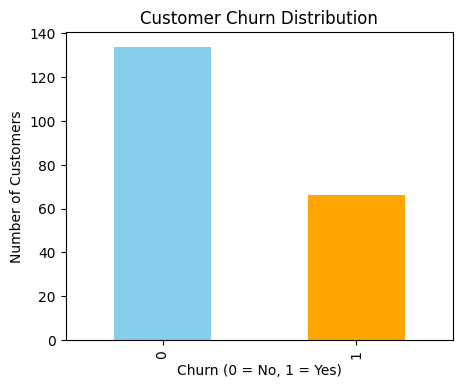

In [7]:
plt.figure(figsize=(5,4))
data['Churn'].value_counts().plot(kind='bar', color=['skyblue','orange'])
plt.title("Customer Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.show()

Box-plot Monthly charges by churn

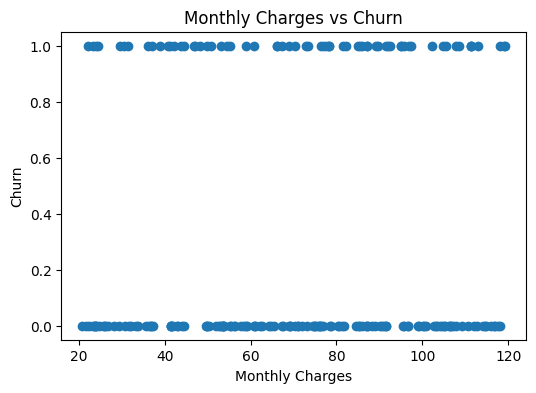

In [8]:
plt.figure(figsize=(6,4))
plt.scatter(data['MonthlyCharges'], data['Churn'])
plt.title("Monthly Charges vs Churn")
plt.xlabel("Monthly Charges")
plt.ylabel("Churn")
plt.show()

Bar chart : Contract Types`

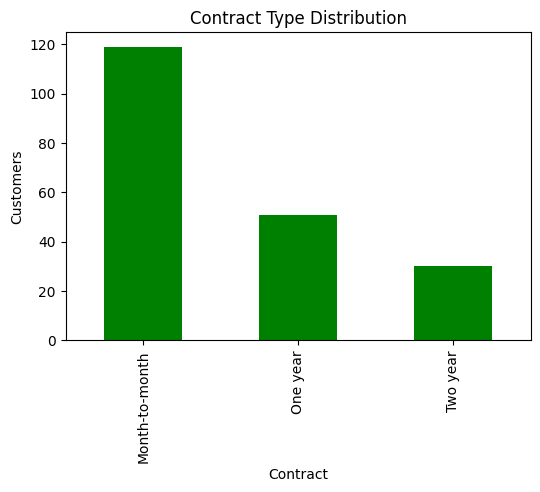

In [9]:
plt.figure(figsize=(6,4))
data['Contract'].value_counts().plot(kind='bar', color='green')
plt.title("Contract Type Distribution")
plt.xlabel("Contract")
plt.ylabel("Customers")
plt.show()


Data Preprocessing, Model Training and Evaluation


Model Accuracy
52.5 %

Confusion Matrix
[[16  9]
 [10  5]]

Classification Report
              precision    recall  f1-score   support

           0       0.62      0.64      0.63        25
           1       0.36      0.33      0.34        15

    accuracy                           0.53        40
   macro avg       0.49      0.49      0.49        40
weighted avg       0.52      0.53      0.52        40



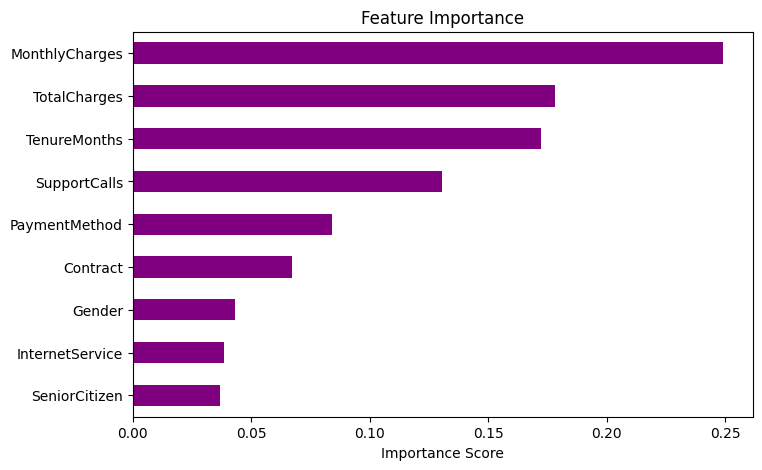


Project Completed Successfully!


In [11]:
# Data Preprocessing
encoder = LabelEncoder()

categorical_columns = [
    'Gender',
    'InternetService',
    'Contract',
    'PaymentMethod'
]

for column in categorical_columns:
    data[column] = encoder.fit_transform(data[column])


# Feature Selection
X = data.drop(['CustomerID', 'Churn'], axis=1)
y = data['Churn']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
# Model Training

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)


# Prediction
y_pred = model.predict(X_test)

# Model Evaluation
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy")
print(round(accuracy * 100, 2), "%")

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Feature Importance
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)
importance = importance.sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind='barh', color='purple')

plt.title("Feature Importance")
plt.xlabel("Importance Score")

plt.show()

print("\nProject Completed Successfully!")